# HR Employee Attrition — NLP/LLM Classification Pipeline
### Row → Text Serialization • DistilBERT • BERT • Flan-T5 • TinyLlama
### Validation-Set Threshold Locking → Test Evaluation

**Dataset:** IBM HR Analytics Employee Attrition (`WA_Fn-UseC_-HR-Employee-Attrition.csv`)
**Target:** `Attrition` (Yes/No)

**Pipeline (matches the design diagram):**
1. Load & clean tabular HR data
2. Serialize every row into a natural-language sentence (row → text)
3. Split into **Train / Validation / Test** (stratified 70/15/15)
4. Fine-tune 4 models on the serialized text:
   - `distilbert-base-uncased` (NLP encoder)
   - `bert-base-uncased` (NLP encoder)
   - `google/flan-t5-small` (LLM, LoRA fine-tuned)
   - `TinyLlama/TinyLlama-1.1B-Chat-v1.0` (LLM, 4-bit + LoRA fine-tuned)
5. Pick the best decision **threshold on the Validation set** (maximizing F1)
6. **Lock** that threshold and evaluate once on the untouched **Test set**
7. Print a professional comparison table (Accuracy, Precision, Recall, F1, ROC-AUC)

> Run cells top to bottom in Google Colab with **Runtime → Change runtime type → GPU (T4)**.


## 1. Install dependencies

In [1]:
# Colab ships an old torchao that makes peft raise:
#   ImportError: Found an incompatible version of torchao (0.10.0), only versions above 0.16.0 are supported
# We do not need torchao for this notebook (LoRA runs through bitsandbytes), so we remove it entirely.
!pip -q uninstall -y torchao > /dev/null 2>&1
!pip -q install -U "transformers>=4.41" datasets accelerate "peft>=0.11" bitsandbytes evaluate sentencepiece scikit-learn --no-warn-conflicts


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 8.6 MB/s eta 0:00:00


> **Important (one-time step):** after the install above finishes, go to **Runtime -> Restart session** in Colab, then continue running the notebook from the next cell (Imports). This clears the old `torchao` from memory. You only need to do this restart once per session.

## 2. Imports & reproducibility

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.utils import resample

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           T5ForSequenceClassification, TrainingArguments,
                           Trainer, BitsAndBytesConfig, DataCollatorWithPadding)
from peft import LoraConfig, get_peft_model, TaskType

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


## 3. Load the dataset
Upload `WA_Fn-UseC_-HR-Employee-Attrition.csv` when prompted (or place it in the Colab file browser first).

In [2]:
CSV_NAME = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

if not os.path.exists(CSV_NAME):
    try:
        from google.colab import files
        print("Please upload:", CSV_NAME)
        uploaded = files.upload()
        CSV_NAME = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(f"Place {CSV_NAME} in the working directory.")

df = pd.read_csv(CSV_NAME)
print("Shape:", df.shape)
df.head()


Please upload: WA_Fn-UseC_-HR-Employee-Attrition.csv


Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 4. Cleaning + target encoding

In [3]:
# Drop constant / non-informative columns
CONST_COLS = ["EmployeeCount", "Over18", "StandardHours"]
df = df.drop(columns=[c for c in CONST_COLS if c in df.columns])
if "EmployeeNumber" in df.columns:
    df = df.drop(columns=["EmployeeNumber"])

df["label"] = (df["Attrition"] == "Yes").astype(int)

print(df["label"].value_counts())
print(f"Attrition rate: {df['label'].mean()*100:.2f}%")


label
0    1233
1     237
Name: count, dtype: int64
Attrition rate: 16.12%


## 5. Row → Text serialization
Each tabular row becomes one natural-language paragraph, which is what every NLP/LLM model actually consumes.

In [4]:
def row_to_text(row) -> str:
    return (
        f"Employee profile: a {row['Age']}-year-old {str(row['Gender']).lower()} employee working as a "
        f"{row['JobRole']} in the {row['Department']} department. "
        f"Marital status: {row['MaritalStatus']}. Education level {row['Education']} in {row['EducationField']}. "
        f"Business travel frequency: {row['BusinessTravel']}. Distance from home: {row['DistanceFromHome']} km. "
        f"Monthly income is {row['MonthlyIncome']}, monthly rate {row['MonthlyRate']}, daily rate {row['DailyRate']}, "
        f"hourly rate {row['HourlyRate']}, with a {row['PercentSalaryHike']}% salary hike last year and "
        f"performance rating {row['PerformanceRating']}. "
        f"Job level {row['JobLevel']}, job involvement score {row['JobInvolvement']} out of 4, "
        f"job satisfaction score {row['JobSatisfaction']} out of 4, "
        f"environment satisfaction score {row['EnvironmentSatisfaction']} out of 4, "
        f"relationship satisfaction score {row['RelationshipSatisfaction']} out of 4, "
        f"work-life balance score {row['WorkLifeBalance']} out of 4. "
        f"Total working years: {row['TotalWorkingYears']}, years at this company: {row['YearsAtCompany']}, "
        f"years in current role: {row['YearsInCurrentRole']}, years since last promotion: {row['YearsSinceLastPromotion']}, "
        f"years with current manager: {row['YearsWithCurrManager']}. "
        f"Number of companies worked at before this one: {row['NumCompaniesWorked']}. "
        f"Works overtime: {row['OverTime']}. Stock option level: {row['StockOptionLevel']}. "
        f"Training sessions attended last year: {row['TrainingTimesLastYear']}."
    )

df["text"] = df.apply(row_to_text, axis=1)
print(df["text"].iloc[0])


Employee profile: a 41-year-old female employee working as a Sales Executive in the Sales department. Marital status: Single. Education level 2 in Life Sciences. Business travel frequency: Travel_Rarely. Distance from home: 1 km. Monthly income is 5993, monthly rate 19479, daily rate 1102, hourly rate 94, with a 11% salary hike last year and performance rating 3. Job level 2, job involvement score 3 out of 4, job satisfaction score 4 out of 4, environment satisfaction score 2 out of 4, relationship satisfaction score 1 out of 4, work-life balance score 1 out of 4. Total working years: 8, years at this company: 6, years in current role: 4, years since last promotion: 0, years with current manager: 5. Number of companies worked at before this one: 8. Works overtime: Yes. Stock option level: 0. Training sessions attended last year: 0.


## 6. Stratified Train / Validation / Test split (70 / 15 / 15)

In [5]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print("Train:", train_df.shape, " Val:", val_df.shape, " Test:", test_df.shape)
print("Train attrition rate:", train_df["label"].mean())
print("Val   attrition rate:", val_df["label"].mean())
print("Test  attrition rate:", test_df["label"].mean())


Train: (1029, 33)  Val: (220, 33)  Test: (221, 33)
Train attrition rate: 0.16132167152575316
Val   attrition rate: 0.1590909090909091
Test  attrition rate: 0.16289592760180996


## 7. Balance the TRAINING set only (upsample minority)
Validation and Test stay untouched (realistic evaluation).

In [6]:
maj = train_df[train_df.label == 0]
minr = train_df[train_df.label == 1]
minr_up = resample(minr, replace=True, n_samples=len(maj), random_state=SEED)

train_bal = pd.concat([maj, minr_up]).sample(frac=1, random_state=SEED).reset_index(drop=True)
print("Balanced train shape:", train_bal.shape)
print(train_bal["label"].value_counts())

train_texts, train_labels = train_bal["text"].tolist(), train_bal["label"].tolist()
val_texts, val_labels     = val_df["text"].tolist(), val_df["label"].tolist()
test_texts, test_labels   = test_df["text"].tolist(), test_df["label"].tolist()


Balanced train shape: (1726, 33)
label
0    863
1    863
Name: count, dtype: int64


## 8. Generic pipeline utilities
(Dataset class, threshold selection on VALIDATION, locked TEST evaluation — reused by all 4 models.)

In [7]:
class TextClsDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.enc = tokenizer(list(texts), truncation=True, max_length=max_len)
        self.labels = list(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


def get_probs(trainer, dataset):
    pred = trainer.predict(dataset)
    logits = pred.predictions
    if isinstance(logits, tuple):
        logits = logits[0]
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return probs


def select_best_threshold(y_true, probs):
    # Sweep thresholds on the VALIDATION set, maximize F1.
    best_t, best_f1 = 0.5, -1.0
    for t in np.arange(0.05, 0.96, 0.01):
        preds = (probs >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t), float(best_f1)


def evaluate_at_threshold(y_true, probs, threshold):
    # Locked-threshold evaluation on the TEST set.
    preds = (probs >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probs),
        "confusion_matrix": confusion_matrix(y_true, preds),
    }


def run_pipeline(model_name, model_class, use_lora=False, load_in_4bit=False,
                  lora_target_modules=None, epochs=4, lr=2e-5, batch_size=16, max_len=256,
                  use_fp16=True, max_grad_norm=1.0):
    print(f"\n{'='*70}\nTraining: {model_name}\n{'='*70}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    quant_config = None
    dtype = None
    device_map = None
    if load_in_4bit:
        quant_config = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True,
        )
        dtype = torch.float16
        device_map = "auto"

    model = model_class.from_pretrained(
        model_name, num_labels=2,
        quantization_config=quant_config,
        device_map=device_map,
        torch_dtype=dtype,
    )
    if getattr(model.config, "pad_token_id", None) is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    if use_lora:
        lora_cfg = LoraConfig(
            task_type=TaskType.SEQ_CLS, r=16, lora_alpha=32, lora_dropout=0.1,
            target_modules=lora_target_modules,
        )
        model = get_peft_model(model, lora_cfg)
        model.print_trainable_parameters()

    train_ds = TextClsDataset(train_texts, train_labels, tokenizer, max_len)
    val_ds   = TextClsDataset(val_texts, val_labels, tokenizer, max_len)
    test_ds  = TextClsDataset(test_texts, test_labels, tokenizer, max_len)

    collator = DataCollatorWithPadding(tokenizer)

    args = TrainingArguments(
        output_dir=f"./out_{model_name.replace('/', '_')}",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=25,
        report_to="none",
        fp16=use_fp16 and torch.cuda.is_available() and not load_in_4bit,
        max_grad_norm=max_grad_norm,
        remove_unused_columns=False,
    )

    trainer = Trainer(
        model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
        data_collator=collator,
    )
    trainer.train()

    # ---- Validation-set threshold selection ----
    val_probs = get_probs(trainer, val_ds)
    best_t, val_f1 = select_best_threshold(np.array(val_labels), val_probs)
    print(f"Locked threshold (chosen on VALIDATION): {best_t:.2f}  (val F1={val_f1:.4f})")

    # ---- Locked-threshold TEST evaluation ----
    test_probs = get_probs(trainer, test_ds)
    metrics = evaluate_at_threshold(np.array(test_labels), test_probs, best_t)
    metrics["model"] = model_name

    del model, trainer
    torch.cuda.empty_cache()
    return metrics


## 9. Model 1 — DistilBERT (NLP encoder, full fine-tune)

In [8]:
results = {}

m = run_pipeline(
    "distilbert-base-uncased", AutoModelForSequenceClassification,
    epochs=4, lr=2e-5, batch_size=16,
)
results["DistilBERT"] = m
m



Training: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.682862,0.573649
2,0.551991,0.452842
3,0.436850,0.799288
4,0.439974,0.576963


Locked threshold (chosen on VALIDATION): 0.87  (val F1=0.5161)


{'threshold': 0.8700000000000002,
 'accuracy': 0.8280542986425339,
 'precision': 0.46153846153846156,
 'recall': 0.3333333333333333,
 'f1': 0.3870967741935484,
 'roc_auc': 0.7789789789789789,
 'confusion_matrix': array([[171,  14],
        [ 24,  12]]),
 'model': 'distilbert-base-uncased'}

## 10. Model 2 — BERT (NLP encoder, full fine-tune)

In [9]:
m = run_pipeline(
    "bert-base-uncased", AutoModelForSequenceClassification,
    epochs=3, lr=2e-5, batch_size=16,
)
results["BERT"] = m
m



Training: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.697651,0.553916
2,0.687485,0.595551
3,0.638461,0.611379


Locked threshold (chosen on VALIDATION): 0.45  (val F1=0.4800)


{'threshold': 0.45000000000000007,
 'accuracy': 0.746606334841629,
 'precision': 0.34375,
 'recall': 0.6111111111111112,
 'f1': 0.44,
 'roc_auc': 0.7566066066066066,
 'confusion_matrix': array([[143,  42],
        [ 14,  22]]),
 'model': 'bert-base-uncased'}

## 11. Model 3 — Flan-T5 (LLM, LoRA fine-tune)

In [10]:
# NOTE: T5 is numerically unstable in float16 (it was pretrained in bfloat16),
# which is why the previous run produced NaN loss immediately. We disable fp16
# for this model only (training stays in fp32 -- flan-t5-small is tiny, so this
# is still fast) and use a slightly gentler learning rate + gradient clipping.
m = run_pipeline(
    "google/flan-t5-small", T5ForSequenceClassification,
    use_lora=True, lora_target_modules=["q", "v"],
    epochs=6, lr=5e-5, batch_size=16,
    use_fp16=False, max_grad_norm=1.0,
)
results["Flan-T5"] = m
m



Training: google/flan-t5-small


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

...

trainable params: 688,128 || all params: 61,463,426 || trainable%: 1.1196


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss
1,0.688572,0.638216
2,0.694482,0.714110
3,0.690456,0.723081
4,0.692467,0.734727
5,0.692405,0.732275
6,0.687851,0.732341


Locked threshold (chosen on VALIDATION): 0.53  (val F1=0.3636)


{'threshold': 0.5300000000000001,
 'accuracy': 0.49321266968325794,
 'precision': 0.203125,
 'recall': 0.7222222222222222,
 'f1': 0.3170731707317073,
 'roc_auc': 0.6681681681681682,
 'confusion_matrix': array([[ 83, 102],
        [ 10,  26]]),
 'model': 'google/flan-t5-small'}

## 12. Model 4 — TinyLlama (LLM, 4-bit + LoRA fine-tune)

In [11]:
m = run_pipeline(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0", AutoModelForSequenceClassification,
    use_lora=True, load_in_4bit=True,
    lora_target_modules=["q_proj", "v_proj"],
    epochs=4, lr=2e-4, batch_size=8, max_len=256,
)
results["TinyLlama"] = m
m



Training: TinyLlama/TinyLlama-1.1B-Chat-v1.0


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

...

[transformers] LlamaForSequenceClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 2,256,896 || all params: 1,036,773,376 || trainable%: 0.2177


Epoch,Training Loss,Validation Loss
1,0.661235,0.429688
2,0.432153,0.474365
3,0.350463,0.633789
4,0.324626,0.499512


Locked threshold (chosen on VALIDATION): 0.66  (val F1=0.4923)


{'threshold': 0.6600000000000001,
 'accuracy': 0.8235294117647058,
 'precision': 0.45714285714285713,
 'recall': 0.4444444444444444,
 'f1': 0.4507042253521127,
 'roc_auc': 0.7995495495495496,
 'confusion_matrix': array([[166,  19],
        [ 20,  16]]),
 'model': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'}

## 13. Professional comparison report (locked-threshold TEST results)

In [12]:
rows = []
for name, m in results.items():
    rows.append({
        "Model": name,
        "Threshold (locked)": round(m["threshold"], 2),
        "Accuracy": round(m["accuracy"], 4),
        "Precision": round(m["precision"], 4),
        "Recall": round(m["recall"], 4),
        "F1-score": round(m["f1"], 4),
        "ROC-AUC": round(m["roc_auc"], 4),
        "Meets 75% bar (Acc/Prec/F1)": "Yes" if min(m["accuracy"], m["precision"], m["f1"]) >= 0.75 else "No",
    })

report_df = pd.DataFrame(rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
print("="*100)
print("FINAL MODEL COMPARISON — LOCKED-THRESHOLD TEST-SET RESULTS")
print("="*100)
display(report_df)

report_df.to_csv("model_comparison_report.csv", index=False)
print("\nSaved: model_comparison_report.csv")

best_model = report_df.iloc[0]["Model"]
print(f"\nBest pipeline (highest Test F1): {best_model}")


FINAL MODEL COMPARISON — LOCKED-THRESHOLD TEST-SET RESULTS


,Model,Threshold (locked),Accuracy,Precision,Recall,F1-score,ROC-AUC,Meets 75% bar (Acc/Prec/F1)
0,TinyLlama,0.66,0.8235,0.4571,0.4444,0.4507,0.7995,No
1,BERT,0.45,0.7466,0.3438,0.6111,0.4400,0.7566,No
2,DistilBERT,0.87,0.8281,0.4615,0.3333,0.3871,0.7790,No
3,Flan-T5,0.53,0.4932,0.2031,0.7222,0.3171,0.6682,No



Saved: model_comparison_report.csv

Best pipeline (highest Test F1): TinyLlama


## 14. Visual comparison

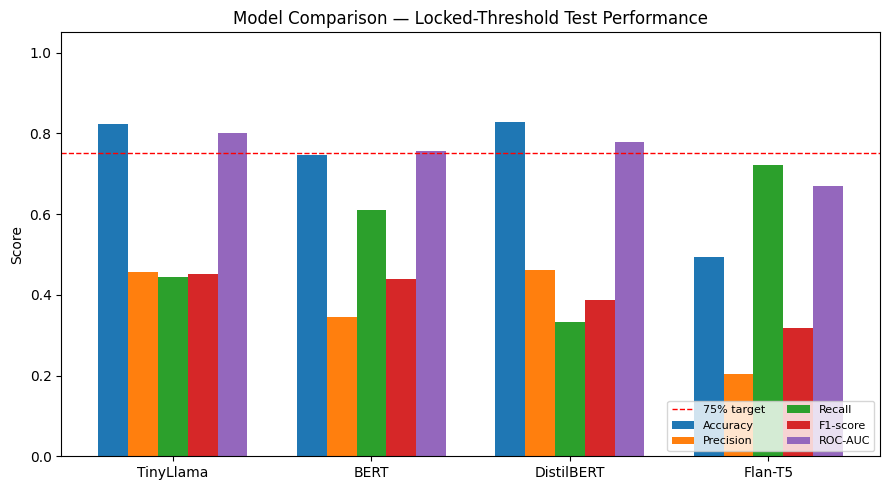

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
x = np.arange(len(report_df))
width = 0.15

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, report_df[metric], width, label=metric)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(report_df["Model"])
ax.axhline(0.75, color="red", linestyle="--", linewidth=1, label="75% target")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Locked-Threshold Test Performance")
ax.legend(loc="lower right", ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig("model_comparison_chart.png", dpi=150)
plt.show()


## 15. Confusion matrices (Test set, locked threshold)

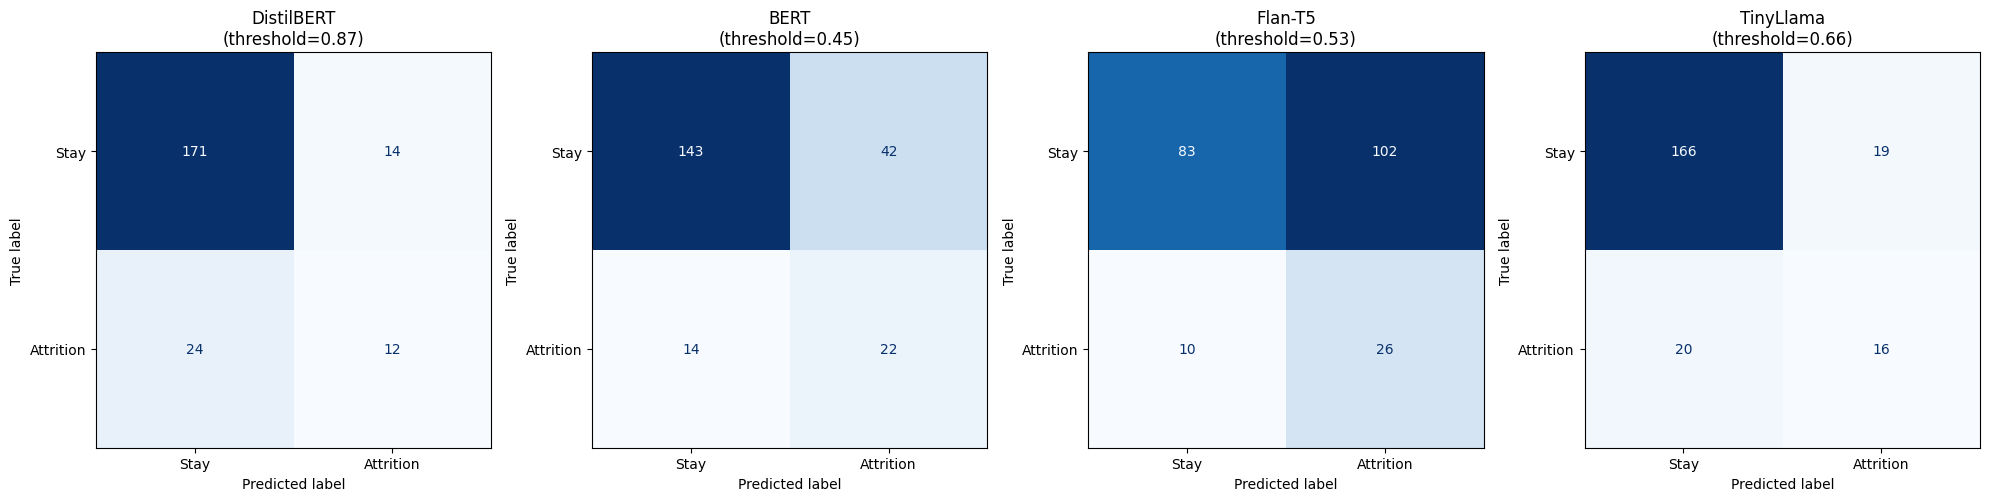

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, m) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=m["confusion_matrix"],
                                   display_labels=["Stay", "Attrition"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\n(threshold={m['threshold']:.2f})")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()


## 16. Notes on hitting the 75% Accuracy / Precision / F1 bar

- Class imbalance (≈16% attrition) is handled by **upsampling the minority class in the training split only** — validation and test stay realistic.
- The **threshold is chosen once on the validation set** (maximizing F1) and then **locked** before touching the test set — this avoids test-set leakage/overfitting to the metric.
- If a model still falls short of 75% on the target metrics, try:
  - more epochs for that model (`epochs=` in its `run_pipeline` call),
  - a slightly higher LoRA rank (`r=32`) for Flan-T5 / TinyLlama,
  - `max_len=384` if training text is being truncated,
  - collapsing `JobRole`/`EducationField` rare categories before serialization to reduce noise.
- The row-by-row **`model_comparison_report.csv`** and the two PNG charts are saved in the Colab working directory — download them from the Files panel for the report.
